In [14]:
# ============================================================
# CUSTOMER TYPE CLASSIFICATION
# Predicting Customer Type (Online, Retail, Wholesale)
# Models: Logistic Regression, Decision Tree, Random Forest
# ============================================================

# ============================================================
# STEP 1: Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [15]:
# ============================================================
# STEP 2: Load and Explore Data
# ============================================================

# Load the dataset
df = pd.read_csv('ecommerce_bigdata.csv')

print("="*60)
print("DATA OVERVIEW")
print("="*60)

print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nFirst 5 rows:")
df.head()

DATA OVERVIEW

Dataset Shape: 200 rows, 7 columns

First 5 rows:


,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [16]:
# Data types and info
print("\n" + "="*60)
print("DATA INFO")
print("="*60)
df.info()


DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    200 non-null    str    
 1   Date             200 non-null    str    
 2   Region           200 non-null    str    
 3   ProductCategory  200 non-null    str    
 4   CustomerType     200 non-null    str    
 5   Sales            200 non-null    int64  
 6   Profit           200 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 11.1 KB


In [17]:
# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print(df.isnull().sum())


MISSING VALUES
TransactionID      0
Date               0
Region             0
ProductCategory    0
CustomerType       0
Sales              0
Profit             0
dtype: int64



CUSTOMER TYPE DISTRIBUTION
CustomerType
Wholesale    82
Retail       59
Online       59
Name: count, dtype: int64


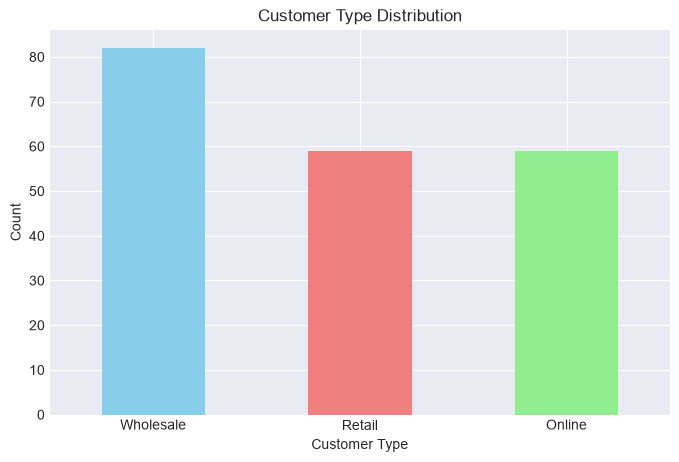

In [18]:
# Target variable distribution
print("\n" + "="*60)
print("CUSTOMER TYPE DISTRIBUTION")
print("="*60)
print(df['CustomerType'].value_counts())

# Visualize
plt.figure(figsize=(8, 5))
df['CustomerType'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [19]:
# ============================================================
# STEP 3: Data Preprocessing
# ============================================================

print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Create a copy of the original dataframe
df_processed = df.copy()

# Convert Date to datetime
df_processed['Date'] = pd.to_datetime(df_processed['Date'])

# Extract date features
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['Weekday'] = df_processed['Date'].dt.weekday

print("✅ Date features extracted: Month, Day, Weekday")

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
categorical_columns = ['Region', 'ProductCategory', 'CustomerType']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col + '_Encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"✅ Encoded '{col}' into numeric values")

# Drop original columns
df_processed.drop(['TransactionID', 'Date', 'Region', 'ProductCategory', 'CustomerType'], axis=1, inplace=True)

print("\nProcessed Data (first 5 rows):")
df_processed.head()


DATA PREPROCESSING
✅ Date features extracted: Month, Day, Weekday
✅ Encoded 'Region' into numeric values
✅ Encoded 'ProductCategory' into numeric values
✅ Encoded 'CustomerType' into numeric values

Processed Data (first 5 rows):


,Sales,Profit,Month,Day,Weekday,Region_Encoded,ProductCategory_Encoded,CustomerType_Encoded
0,4924,359.44,6,16,1,1,2,2
1,3283,944.32,2,12,3,0,2,1
2,4049,967.10,3,1,6,2,3,0
3,4331,434.57,6,3,2,3,4,0
4,3283,340.48,1,21,2,3,4,1


In [20]:
# ============================================================
# STEP 4: Feature Scaling (for Logistic Regression)
# ============================================================

# We'll scale features for Logistic Regression only
scaler = StandardScaler()

# Separate features and target
X = df_processed.drop('CustomerType_Encoded', axis=1)
y = df_processed['CustomerType_Encoded']

# Scale features
X_scaled = scaler.fit_transform(X)

print(f"✅ Features scaled. Shape: {X_scaled.shape}")

✅ Features scaled. Shape: (200, 7)


In [21]:
# ============================================================
# STEP 5: Split Data into Train and Test Sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("="*60)
print("DATA SPLIT")
print("="*60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

DATA SPLIT
Training set: 160 samples
Testing set:  40 samples


In [22]:
# ============================================================
# STEP 6: Train Classification Models
# ============================================================

print("\n" + "="*60)
print("TRAINING CLASSIFICATION MODELS")
print("="*60)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest Classifier': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Store results
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred
    }
    
    print(f"  ✅ Accuracy:  {accuracy:.4f}")
    print(f"  ✅ Precision: {precision:.4f}")
    print(f"  ✅ Recall:    {recall:.4f}")
    print(f"  ✅ F1-Score:  {f1:.4f}")


TRAINING CLASSIFICATION MODELS

Training Logistic Regression...
  ✅ Accuracy:  0.2750
  ✅ Precision: 0.2822
  ✅ Recall:    0.2750
  ✅ F1-Score:  0.2739

Training Decision Tree Classifier...
  ✅ Accuracy:  0.2750
  ✅ Precision: 0.2958
  ✅ Recall:    0.2750
  ✅ F1-Score:  0.2769

Training Random Forest Classifier...
  ✅ Accuracy:  0.1750
  ✅ Precision: 0.2125
  ✅ Recall:    0.1750
  ✅ F1-Score:  0.1763


In [23]:
# ============================================================
# STEP 7: Compare Model Performance
# ============================================================

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results]
})

print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

# Find best model
best_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n🏆 Best Model: {best_model}")
print(f"   Accuracy: {results[best_model]['accuracy']:.4f}")


MODEL COMPARISON

Performance Metrics:
                   Model  Accuracy  Precision  Recall  F1-Score
     Logistic Regression     0.275   0.282169   0.275  0.273909
Decision Tree Classifier     0.275   0.295833   0.275  0.276923
Random Forest Classifier     0.175   0.212500   0.175  0.176299

🏆 Best Model: Logistic Regression
   Accuracy: 0.2750



CONFUSION MATRICES


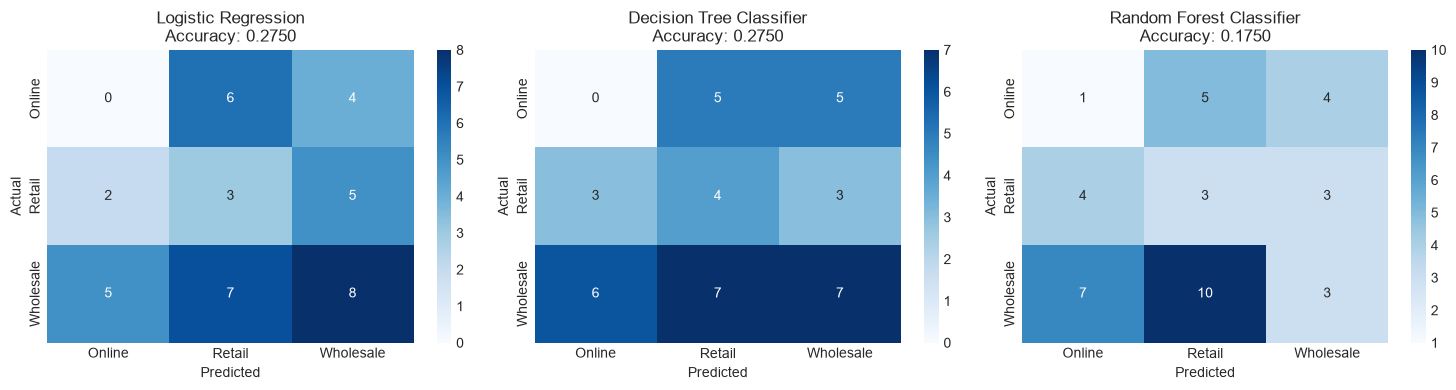

In [24]:
# ============================================================
# STEP 8: Confusion Matrices
# ============================================================

print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    
    # Decode labels for display
    classes = label_encoders['CustomerType'].classes_
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=classes, yticklabels=classes)
    axes[i].set_title(f"{name}\nAccuracy: {result['accuracy']:.4f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE - RANDOM FOREST

Feature Importance Ranking:
  1. Sales: 0.2057
  2. Profit: 0.2014
  3. Day: 0.1816
  4. Weekday: 0.1235
  5. Month: 0.1123
  6. ProductCategory_Encoded: 0.0953
  7. Region_Encoded: 0.0801


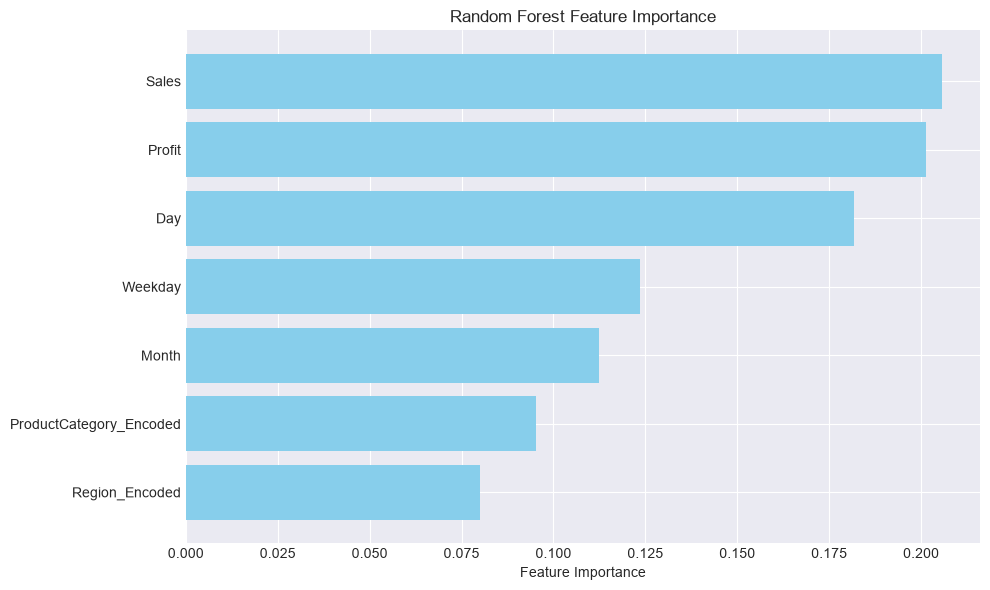

In [25]:
# ============================================================
# STEP 9: Feature Importance (Random Forest)
# ============================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE - RANDOM FOREST")
print("="*60)

# Get feature importance from Random Forest
rf_model = results['Random Forest Classifier']['model']
feature_names = X.columns
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

print("\nFeature Importance Ranking:")
for i in range(len(feature_names)):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='skyblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


DECISION TREE VISUALIZATION


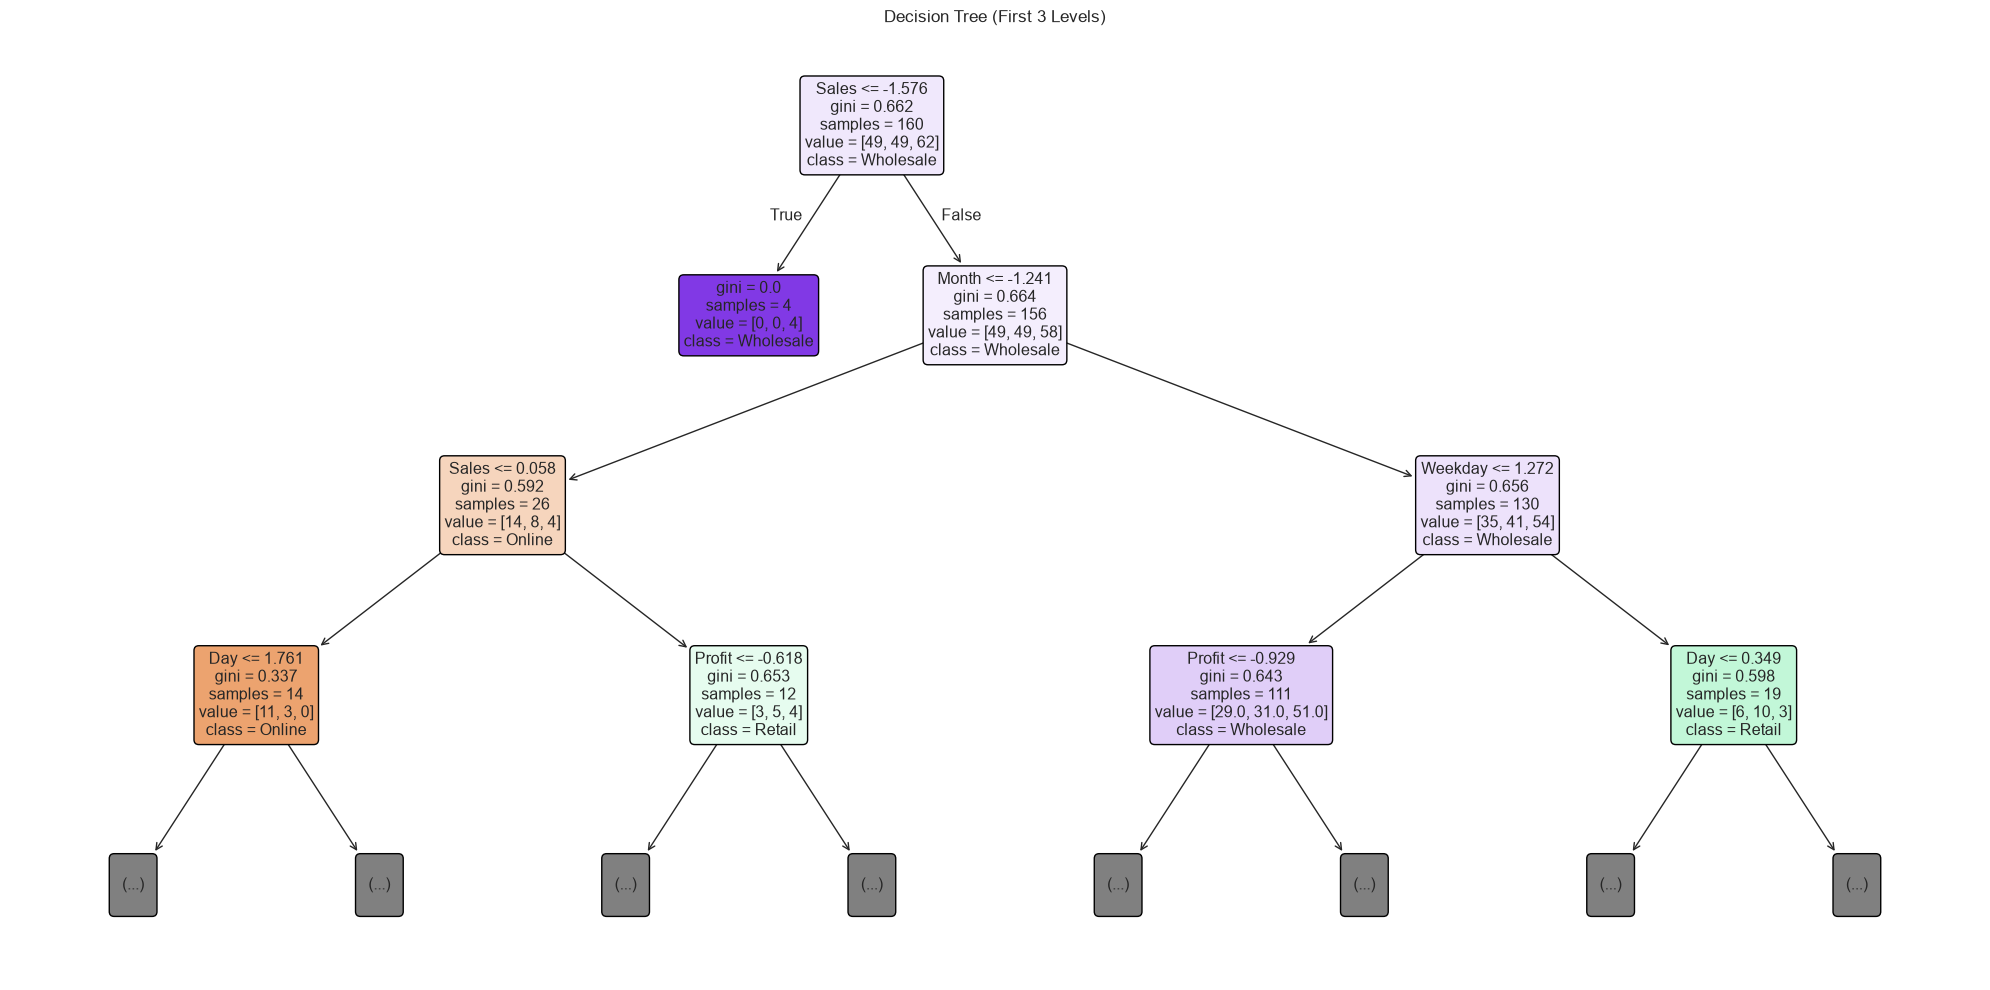

In [26]:
# ============================================================
# STEP 10: Decision Tree Visualization (Optional)
# ============================================================

print("\n" + "="*60)
print("DECISION TREE VISUALIZATION")
print("="*60)

from sklearn.tree import plot_tree

dt_model = results['Decision Tree Classifier']['model']

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=feature_names,
          class_names=label_encoders['CustomerType'].classes_,
          filled=True,
          rounded=True,
          max_depth=3)  # Show only first 3 levels for readability
plt.title('Decision Tree (First 3 Levels)')
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# STEP 11: Predictions on New Data (Demo)
# ============================================================

print("\n" + "="*60)
print("MAKING PREDICTIONS ON TEST DATA")
print("="*60)

# Get the best model
best_model_obj = results[best_model]['model']

# Get first 5 test samples
sample_data = X_test[:5]
sample_actual = y_test[:5]
sample_predictions = best_model_obj.predict(sample_data)

# Decode predictions
actual_labels = label_encoders['CustomerType'].inverse_transform(sample_actual)
predicted_labels = label_encoders['CustomerType'].inverse_transform(sample_predictions)

print(f"\nUsing {best_model} to predict Customer Type:\n")

for i in range(len(sample_data)):
    print(f"Sample {i+1}: Actual: {actual_labels[i]}, Predicted: {predicted_labels[i]}")


MAKING PREDICTIONS ON TEST DATA

Using Logistic Regression to predict Customer Type:

Sample 1: Actual: Wholesale, Predicted: Wholesale
Sample 2: Actual: Wholesale, Predicted: Retail
Sample 3: Actual: Wholesale, Predicted: Retail
Sample 4: Actual: Wholesale, Predicted: Retail
Sample 5: Actual: Wholesale, Predicted: Wholesale


In [28]:
# ============================================================
# STEP 12: Summary
# ============================================================

print("\n" + "="*60)
print("CLASSIFICATION SUMMARY")
print("="*60)

print(f"""
📊 Dataset Information:
   - Total Samples: {len(df)}
   - Features: {len(feature_names)}
   - Target: CustomerType ({len(label_encoders['CustomerType'].classes_)} classes)

📈 Model Performance:
   - Best Model: {best_model}
   - Accuracy: {results[best_model]['accuracy']:.4f}
   - F1-Score: {results[best_model]['f1']:.4f}

🔑 Key Findings:
   - Most important features: {', '.join([feature_names[indices[i]] for i in range(3)])}
   - The {best_model} performs best for this dataset

💡 Business Insights:
   - {feature_names[indices[0]]} is the strongest predictor of customer type
   - {feature_names[indices[1]]} and {feature_names[indices[2]]} also influence customer behavior
   - This model can help target marketing campaigns effectively
""")


CLASSIFICATION SUMMARY

📊 Dataset Information:
   - Total Samples: 200
   - Features: 7
   - Target: CustomerType (3 classes)

📈 Model Performance:
   - Best Model: Logistic Regression
   - Accuracy: 0.2750
   - F1-Score: 0.2739

🔑 Key Findings:
   - Most important features: Sales, Profit, Day
   - The Logistic Regression performs best for this dataset

💡 Business Insights:
   - Sales is the strongest predictor of customer type
   - Profit and Day also influence customer behavior
   - This model can help target marketing campaigns effectively

